In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

# Load untouched raw signals; locate data/ from either the workspace root or notebooks/.
DATA_DIR = next(
    (path for path in (Path.cwd() / "data", Path.cwd().parent / "data")
     if (path / "press_data_normal.csv").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("Could not locate data/press_data_normal.csv")

REQUIRED_COLUMNS = [
    "TimeStamp",
    "AI0_Vibration",
    "AI1_Vibration",
    "AI2_Current",
    "Equipment_state",
]
TIME_GAP_THRESHOLD_SEC = 0.15


def prepare_cycle_data(path):
    df = pd.read_csv(path)
    missing = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns in {path.name}: {missing}")

    # Source timestamps are MM:SS.s clock values that can roll over at 60 minutes.
    parts = df["TimeStamp"].astype("string").str.extract(
        r"^(?P<minutes>\d+):(?P<seconds>\d{2}\.\d+)$"
    )
    if parts.isna().any().any():
        bad_values = df.loc[parts.isna().any(axis=1), "TimeStamp"].head().tolist()
        raise ValueError(f"Unexpected TimeStamp format in {path.name}: {bad_values}")

    minutes = pd.to_numeric(parts["minutes"], errors="raise")
    seconds = pd.to_numeric(parts["seconds"], errors="raise")
    if not minutes.between(0, 60, inclusive="left").all():
        raise ValueError(f"Minutes field is outside [0, 60) in {path.name}")
    if not seconds.between(0, 60, inclusive="left").all():
        raise ValueError(f"Seconds field is outside [0, 60) in {path.name}")

    clock_sec = minutes * 60 + seconds
    wrap = clock_sec.diff().lt(-1800)
    elapsed_sec = clock_sec + wrap.cumsum().mul(3600)

    df = df.copy()
    df["source_row"] = np.arange(len(df))
    df["elapsed_sec"] = elapsed_sec
    df["dt_sec"] = df["elapsed_sec"].diff()
    df["is_duplicate"] = df["elapsed_sec"].duplicated(keep="first")
    df["is_nonincreasing"] = df["dt_sec"].le(0).fillna(False)
    df["is_large_gap"] = df["dt_sec"].gt(TIME_GAP_THRESHOLD_SEC).fillna(False)

    segment_start = (
        df["dt_sec"].isna()
        | df["is_nonincreasing"]
        | df["is_large_gap"]
    )
    df["segment_id"] = segment_start.cumsum().sub(1).astype("int64")
    return df


normal = prepare_cycle_data(DATA_DIR / "press_data_normal.csv")
outlier = prepare_cycle_data(DATA_DIR / "outlier_data.csv")


def quality_summary(df, dataset_name):
    intervals = df["dt_sec"].dropna()
    segment_sizes = df.groupby("segment_id", sort=False).size()
    return {
        "dataset": dataset_name,
        "rows": len(df),
        "invalid_signal_rows": int(df[REQUIRED_COLUMNS[1:4]].isna().any(axis=1).sum()),
        "duplicate_timestamps": int(df["is_duplicate"].sum()),
        "nonincreasing_intervals": int(df["is_nonincreasing"].sum()),
        "large_gaps": int(df["is_large_gap"].sum()),
        "median_positive_dt_sec": intervals[intervals > 0].median(),
        "fraction_dt_0_1_sec": (intervals.sub(0.1).abs() < 1e-9).mean(),
        "segments": int(df["segment_id"].nunique()),
        "longest_segment_rows": int(segment_sizes.max()),
    }


quality = pd.DataFrame(
    [quality_summary(normal, "normal"), quality_summary(outlier, "outlier")]
)
display(quality)

,dataset,rows,invalid_signal_rows,duplicate_timestamps,nonincreasing_intervals,large_gaps,median_positive_dt_sec,fraction_dt_0_1_sec,segments,longest_segment_rows
0,normal,20000,0,2,2,599,0.1,0.969947,603,50
1,outlier,600,0,0,0,20,0.1,0.966555,22,50


In [2]:
from scipy.signal import find_peaks, periodogram

CHANNELS = ["AI0_Vibration", "AI1_Vibration", "AI2_Current"]
SAMPLE_RATE_HZ = 10.0
MIN_SEGMENT_ROWS = 30
MIN_PERIOD_SEC = 0.3
MAX_PERIOD_SEC = 4.0


def segment_acf(values, max_lag):
    values = np.asarray(values, dtype=float)
    values = values - values.mean()
    denominator = np.dot(values, values)
    if denominator <= 0:
        return None
    acf = np.correlate(values, values, mode="full")[len(values) - 1:]
    acf = acf[:max_lag + 1] / denominator
    return acf


def analyze_channel(df, column):
    max_lag = min(int(MAX_PERIOD_SEC * SAMPLE_RATE_HZ), 40)
    min_lag = int(MIN_PERIOD_SEC * SAMPLE_RATE_HZ)
    acf_sum = np.zeros(max_lag + 1)
    acf_weight = np.zeros(max_lag + 1)
    spectra = []
    peak_intervals = []
    eligible_segments = 0
    frequencies = np.fft.rfftfreq(256, d=1 / SAMPLE_RATE_HZ)

    for segment_id, group in df.groupby("segment_id", sort=False):
        if len(group) < MIN_SEGMENT_ROWS:
            continue
        values = group[column].to_numpy(dtype=float)
        if not np.isfinite(values).all():
            continue
        eligible_segments += 1

        acf = segment_acf(values, min(max_lag, len(values) - 1))
        if acf is not None:
            acf_sum[:len(acf)] += acf * len(values)
            acf_weight[:len(acf)] += len(values)

        _, power = periodogram(
            values,
            fs=SAMPLE_RATE_HZ,
            nfft=256,
            detrend="constant",
            scaling="spectrum",
        )
        if power.max() > 0:
            spectra.append(power / power.max())

        # A short median is used only to propose extrema; raw columns stay unchanged.
        smoothed = pd.Series(values).rolling(3, center=True, min_periods=1).median()
        prominence = max(float(smoothed.std()) * 0.5, np.finfo(float).eps)
        peaks, _ = find_peaks(smoothed.to_numpy(), distance=3, prominence=prominence)
        if len(peaks) > 1:
            peak_intervals.extend(np.diff(peaks) / SAMPLE_RATE_HZ)

    acf = np.divide(acf_sum, acf_weight, out=np.full_like(acf_sum, np.nan), where=acf_weight > 0)
    acf_peaks, _ = find_peaks(np.nan_to_num(acf), distance=2, prominence=0.05)
    acf_peaks = [lag for lag in acf_peaks if min_lag <= lag <= max_lag]
    acf_peaks = sorted(acf_peaks, key=lambda lag: acf[lag], reverse=True)

    mean_power = np.mean(spectra, axis=0) if spectra else np.array([])
    band = (frequencies >= 1 / MAX_PERIOD_SEC) & (frequencies <= 1 / MIN_PERIOD_SEC)
    band_indices = np.flatnonzero(band)
    psd_candidates = band_indices[np.argsort(mean_power[band])[::-1][:5]] if len(mean_power) else []

    intervals = np.asarray(peak_intervals, dtype=float)
    return {
        "channel": column,
        "eligible_segments": eligible_segments,
        "peak_intervals_count": len(intervals),
        "peak_interval_median_sec": float(np.median(intervals)) if len(intervals) else np.nan,
        "peak_interval_q25_sec": float(np.quantile(intervals, 0.25)) if len(intervals) else np.nan,
        "peak_interval_q75_sec": float(np.quantile(intervals, 0.75)) if len(intervals) else np.nan,
        "acf_top_lag_sec": acf_peaks[0] / SAMPLE_RATE_HZ if acf_peaks else np.nan,
        "acf_top_value": float(acf[acf_peaks[0]]) if acf_peaks else np.nan,
        "psd_top_period_sec": float(1 / frequencies[psd_candidates[0]]) if len(psd_candidates) else np.nan,
        "acf": acf,
        "frequencies": frequencies,
        "mean_normalized_power": mean_power,
        "peak_intervals_sec": intervals,
    }


normal_cycle_results = {
    channel: analyze_channel(normal, channel) for channel in CHANNELS
}
cycle_candidates = pd.DataFrame(
    [{key: value for key, value in result.items() if key not in {
        "acf", "frequencies", "mean_normalized_power", "peak_intervals_sec"
    }} for result in normal_cycle_results.values()]
)
cycle_candidates["interpretation"] = (
    "Exploratory periodicity candidate only; confirm against aligned raw cycles."
)
display(cycle_candidates)

,channel,eligible_segments,peak_intervals_count,peak_interval_median_sec,peak_interval_q25_sec,peak_interval_q75_sec,acf_top_lag_sec,acf_top_value,psd_top_period_sec,interpretation
0,AI0_Vibration,360,1536,0.7,0.6,0.9,0.6,0.446127,0.556522,Exploratory periodicity candidate only; confir...
1,AI1_Vibration,360,2018,0.6,0.5,0.6,1.1,0.594433,0.556522,Exploratory periodicity candidate only; confir...
2,AI2_Current,360,475,1.7,1.6,1.7,1.6,0.622350,1.706667,Exploratory periodicity candidate only; confir...


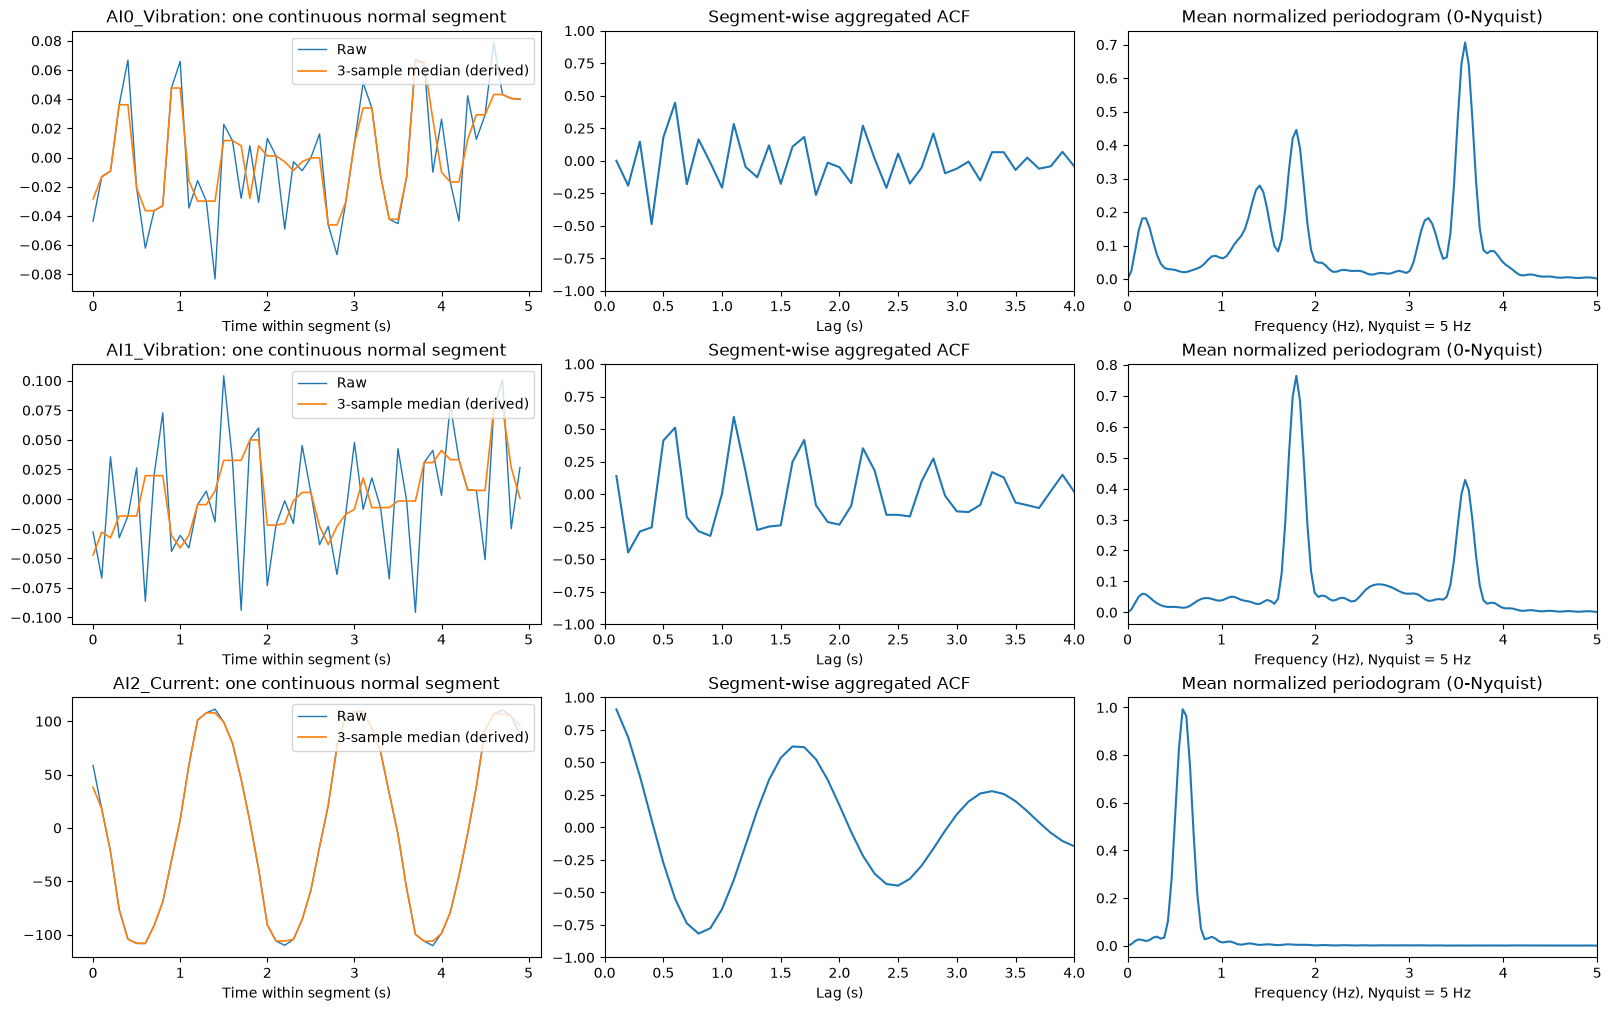

Representative normal segment_id: 5, rows: 50
The median trace is derived for visualization only; raw channel values are unchanged.


In [3]:
import matplotlib.pyplot as plt

normal_segment_sizes = normal.groupby("segment_id", sort=False).size()
representative_segment_id = normal_segment_sizes[normal_segment_sizes >= MIN_SEGMENT_ROWS].idxmax()
representative = normal.loc[normal["segment_id"] == representative_segment_id]

fig, axes = plt.subplots(len(CHANNELS), 3, figsize=(16, 10), constrained_layout=True)
for row, channel in enumerate(CHANNELS):
    values = representative[channel].to_numpy(dtype=float)
    relative_time = np.arange(len(values)) / SAMPLE_RATE_HZ
    smoothed = pd.Series(values).rolling(3, center=True, min_periods=1).median()
    result = normal_cycle_results[channel]

    axes[row, 0].plot(relative_time, values, linewidth=1, label="Raw")
    axes[row, 0].plot(relative_time, smoothed, linewidth=1.2, label="3-sample median (derived)")
    axes[row, 0].set_title(f"{channel}: one continuous normal segment")
    axes[row, 0].set_xlabel("Time within segment (s)")
    axes[row, 0].legend(loc="upper right")

    lags = np.arange(len(result["acf"])) / SAMPLE_RATE_HZ
    axes[row, 1].plot(lags[1:], result["acf"][1:])
    axes[row, 1].set_xlim(0, MAX_PERIOD_SEC)
    axes[row, 1].set_ylim(-1, 1)
    axes[row, 1].set_title("Segment-wise aggregated ACF")
    axes[row, 1].set_xlabel("Lag (s)")

    frequencies = result["frequencies"]
    power = result["mean_normalized_power"]
    axes[row, 2].plot(frequencies, power)
    axes[row, 2].set_xlim(0, SAMPLE_RATE_HZ / 2)
    axes[row, 2].set_title("Mean normalized periodogram (0-Nyquist)")
    axes[row, 2].set_xlabel("Frequency (Hz), Nyquist = 5 Hz")

plt.show()
print(f"Representative normal segment_id: {representative_segment_id}, rows: {len(representative)}")
print("The median trace is derived for visualization only; raw channel values are unchanged.")

In [4]:
CYCLE_ANCHOR = "AI2_Current"
CYCLE_MIN_PEAK_DISTANCE_SAMPLES = 12
TEMPLATE_PHASE_POINTS = 101

cycle_records = []
cycle_waveforms = []

for segment_id, group in normal.groupby("segment_id", sort=False):
    if len(group) < MIN_SEGMENT_ROWS:
        continue

    anchor = group[CYCLE_ANCHOR].to_numpy(dtype=float)
    anchor_smooth = pd.Series(anchor).rolling(3, center=True, min_periods=1).median()
    prominence = max(float(anchor_smooth.std()) * 0.5, np.finfo(float).eps)
    peak_indices, _ = find_peaks(
        anchor_smooth.to_numpy(),
        distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
        prominence=prominence,
    )

    for cycle_number, (start, stop) in enumerate(zip(peak_indices[:-1], peak_indices[1:]), start=1):
        if stop - start < CYCLE_MIN_PEAK_DISTANCE_SAMPLES:
            continue
        cycle = group.iloc[start:stop + 1]
        duration_sec = float(cycle["elapsed_sec"].iloc[-1] - cycle["elapsed_sec"].iloc[0])
        if duration_sec <= 0:
            continue

        record = {
            "segment_id": int(segment_id),
            "cycle_number_in_segment": cycle_number,
            "start_source_row": int(cycle["source_row"].iloc[0]),
            "end_source_row": int(cycle["source_row"].iloc[-1]),
            "duration_sec": duration_sec,
        }
        phase = np.linspace(0, 1, TEMPLATE_PHASE_POINTS)
        cycle_phase = np.linspace(0, 1, len(cycle))
        for channel in CHANNELS:
            values = cycle[channel].to_numpy(dtype=float)
            rms = float(np.sqrt(np.mean(np.square(values))))
            record[f"{channel}_mean"] = float(np.mean(values))
            record[f"{channel}_std"] = float(np.std(values, ddof=1))
            record[f"{channel}_rms"] = rms
            record[f"{channel}_peak_to_peak"] = float(np.ptp(values))
            record[f"{channel}_energy"] = float(np.sum(np.square(values)))
            record[f"{channel}_crest_factor"] = float(np.max(np.abs(values)) / rms) if rms > 0 else np.nan
            cycle_waveforms.append({
                "segment_id": int(segment_id),
                "cycle_number_in_segment": cycle_number,
                "channel": channel,
                "phase": phase,
                "values": np.interp(phase, cycle_phase, values),
            })
        cycle_records.append(record)

cycle_features = pd.DataFrame(cycle_records)
if cycle_features.empty:
    raise ValueError("No candidate cycles were formed; inspect anchor peak settings and segment lengths.")

cycle_feature_columns = [f"{channel}_rms" for channel in CHANNELS]
cycle_templates = {}
for channel in CHANNELS:
    waveforms = [item["values"] for item in cycle_waveforms if item["channel"] == channel]
    template = np.median(np.vstack(waveforms), axis=0)
    cycle_templates[channel] = template

    rmse_by_cycle = {}
    for item in cycle_waveforms:
        if item["channel"] == channel:
            rmse_by_cycle[(item["segment_id"], item["cycle_number_in_segment"])] = float(
                np.sqrt(np.mean(np.square(item["values"] - template)))
            )
    cycle_features[f"{channel}_template_rmse"] = [
        rmse_by_cycle[(row.segment_id, row.cycle_number_in_segment)]
        for row in cycle_features.itertuples()
    ]

print(
    f"Provisional cycles: {len(cycle_features)}; "
    f"median duration: {cycle_features['duration_sec'].median():.2f} s; "
    f"IQR: {cycle_features['duration_sec'].quantile(0.25):.2f}-"
    f"{cycle_features['duration_sec'].quantile(0.75):.2f} s"
)
print("These are exploratory normal-data templates, not validated cycle labels.")
display(cycle_features.head())

Provisional cycles: 475; median duration: 1.70 s; IQR: 1.60-1.70 s
These are exploratory normal-data templates, not validated cycle labels.


,segment_id,cycle_number_in_segment,start_source_row,end_source_row,duration_sec,AI0_Vibration_mean,AI0_Vibration_std,AI0_Vibration_rms,AI0_Vibration_peak_to_peak,AI0_Vibration_energy,...,AI1_Vibration_crest_factor,AI2_Current_mean,AI2_Current_std,AI2_Current_rms,AI2_Current_peak_to_peak,AI2_Current_energy,AI2_Current_crest_factor,AI0_Vibration_template_rmse,AI1_Vibration_template_rmse,AI2_Current_template_rmse
0,1,1,17,34,1.7,-0.013839,0.074322,0.073542,0.320468,0.097351,...,1.615857,16.322078,159.118021,155.493952,439.24885,435210.643180,1.414406,0.062458,0.145686,47.890337
1,2,1,53,70,1.7,0.008140,0.081634,0.079751,0.244890,0.114483,...,1.698016,14.894984,152.289846,148.746773,433.55648,398260.843641,1.462473,0.058767,0.118349,41.048809
2,5,1,125,142,1.7,-0.016340,0.030694,0.034011,0.105994,0.020822,...,2.102431,8.301663,85.836268,83.829927,221.30086,126494.221115,1.327636,0.031216,0.038183,22.825229
3,6,1,164,181,1.7,-0.016352,0.057693,0.058403,0.201815,0.061397,...,1.694571,16.625710,159.593477,155.985537,441.70707,437966.780013,1.421493,0.049678,0.131746,48.783737
4,6,2,181,197,1.6,0.019753,0.071407,0.072036,0.273807,0.088217,...,1.629790,4.864406,158.286431,153.637421,438.96752,401275.771834,1.443218,0.066536,0.123530,45.847403


In [5]:
def extract_candidate_cycles(df, dataset_name):
    records = []
    for segment_id, group in df.groupby("segment_id", sort=False):
        if len(group) < MIN_SEGMENT_ROWS:
            continue
        anchor = group[CYCLE_ANCHOR].to_numpy(dtype=float)
        anchor_smooth = pd.Series(anchor).rolling(3, center=True, min_periods=1).median()
        prominence = max(float(anchor_smooth.std()) * 0.5, np.finfo(float).eps)
        peaks, _ = find_peaks(
            anchor_smooth.to_numpy(),
            distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
            prominence=prominence,
        )
        for cycle_number, (start, stop) in enumerate(zip(peaks[:-1], peaks[1:]), start=1):
            cycle = group.iloc[start:stop + 1]
            duration_sec = float(cycle["elapsed_sec"].iloc[-1] - cycle["elapsed_sec"].iloc[0])
            if duration_sec <= 0:
                continue
            phase = np.linspace(0, 1, TEMPLATE_PHASE_POINTS)
            cycle_phase = np.linspace(0, 1, len(cycle))
            record = {
                "dataset": dataset_name,
                "segment_id": int(segment_id),
                "cycle_number_in_segment": cycle_number,
                "duration_sec": duration_sec,
            }
            for channel in CHANNELS:
                values = cycle[channel].to_numpy(dtype=float)
                aligned = np.interp(phase, cycle_phase, values)
                record[f"{channel}_rms"] = float(np.sqrt(np.mean(np.square(values))))
                record[f"{channel}_template_rmse"] = float(
                    np.sqrt(np.mean(np.square(aligned - cycle_templates[channel])))
                )
            records.append(record)
    return pd.DataFrame(records)


outlier_cycle_features = extract_candidate_cycles(outlier, "outlier")
normal_cycle_comparison = cycle_features.assign(dataset="normal")[[
    "dataset", "duration_sec",
    "AI0_Vibration_rms", "AI1_Vibration_rms", "AI2_Current_rms",
    "AI0_Vibration_template_rmse", "AI1_Vibration_template_rmse", "AI2_Current_template_rmse",
]]
outlier_cycle_comparison = outlier_cycle_features[[
    "dataset", "duration_sec",
    "AI0_Vibration_rms", "AI1_Vibration_rms", "AI2_Current_rms",
    "AI0_Vibration_template_rmse", "AI1_Vibration_template_rmse", "AI2_Current_template_rmse",
]]
cycle_group_summary = pd.concat(
    [normal_cycle_comparison, outlier_cycle_comparison], ignore_index=True
).groupby("dataset").agg(["count", "median", "std"])

print(f"Normal candidate cycles: {len(normal_cycle_features) if 'normal_cycle_features' in globals() else len(cycle_features)}")
print(f"Outlier candidate cycles: {len(outlier_cycle_features)}")
display(cycle_group_summary)

Normal candidate cycles: 475
Outlier candidate cycles: 8


duration_sec                  AI0_Vibration_rms                      \
               count median       std             count    median       std   
dataset                                                                       
normal           475   1.70  0.046936               475  0.068333  0.022083   
outlier            8   1.55  0.226779                 8  0.453832  0.240550   

        AI1_Vibration_rms                     AI2_Current_rms  ...             \
                    count    median       std           count  ...        std   
dataset                                                        ...              
normal                475  0.091093  0.058003             475  ...  37.708108   
outlier                 8  0.262741  0.084998               8  ...  86.723531   

        AI0_Vibration_template_rmse                      \
                              count    median       std   
dataset                                                   
normal                          475  0.053097  0.018999   
outlier                           8  0.423067  0.234819   

        AI1_Vibration_template_rmse                      \
                              count    median       std   
dataset                                                   
normal                          475  0.079738  0.053551   
outlier                           8  0.247306  0.072942   

        AI2_Current_template_rmse                         
                            count      median        std  
dataset                                                   
normal                        475   24.194145  21.728585  
outlier                         8  130.299034  70.748739  

[2 rows x 21 columns]

## ① Normal Large Gap 구조 검증

`dt_sec > 0.15`인 구간을 제거하거나 보간하지 않고, 간격 분포·발생 행 간 거리·gap 전후의 원본 신호를 함께 확인한다. 분석 결과는 저장/수집 block 구조와 실제 운전 단절을 구별할 수 있는 증거가 있는지 평가하는 용도이며, 원인을 확정하지 않는다.

All timestamp intervals (sec):


,count,min,Q1,median,mean,Q3,95%,max
Normal,19998.0,0.0,0.1,0.1,0.230808,0.1,0.1,16.7
Outlier,598.0,0.1,0.1,0.1,0.276756,0.1,0.1,8.6


Large gap intervals only (dt_sec > 0.15 sec):


,count,min,Q1,median,mean,Q3,95%,max
Normal,599.0,0.2,2.40,4.20,4.467446,5.8,8.600,16.7
Outlier,20.0,1.7,3.45,5.35,5.385000,7.8,8.505,8.6


Normal: rounded gap value counts (0.1 sec resolution)
rounded_dt_sec
0.2      1
1.5      1
1.6      9
1.7     25
1.8     47
1.9     25
2.0     15
2.1     10
2.2      8
2.3      8
2.4      7
2.5      8
2.6      4
2.7      6
2.8      8
2.9      9
3.0     14
3.1     13
3.2     14
3.3     10
3.4      7
3.5      6
3.6      5
3.7      7
3.8      9
3.9      6
4.0      8
4.1      5
4.2      8
4.3      9
4.4     14
4.5     12
4.6     10
4.7     12
4.8      8
4.9      5
5.0      6
5.1      5
5.2      9
5.3      7
5.4      9
5.5     14
5.6      7
5.7     12
5.8     11
5.9      9
6.0     10
6.1      6
6.2      4
6.3      6
6.4      6
6.5      8
6.6      7
6.7      4
6.8      3
6.9      6
7.3      3
7.5      1
7.8      2
8.0      1
8.2      1
8.3      4
8.4     15
8.5     18
8.6      9
8.7      7
8.8      4
8.9      2
9.6      1
9.7      3
15.3     1
15.4     1
16.5     2
16.6     1
16.7     1


Outlier: rounded gap value counts (0.1 sec resolution)
rounded_dt_sec
1.7    1
2.0    1
2.6    1
2.8    1
3.3    1
3.5    1
4.0    1
4.3    1
4.5    1
5.3    1
5.4    1
5.8    1
6.0    1
6.4    1
7.6    1
8.4    1
8.5    3
8.6    1


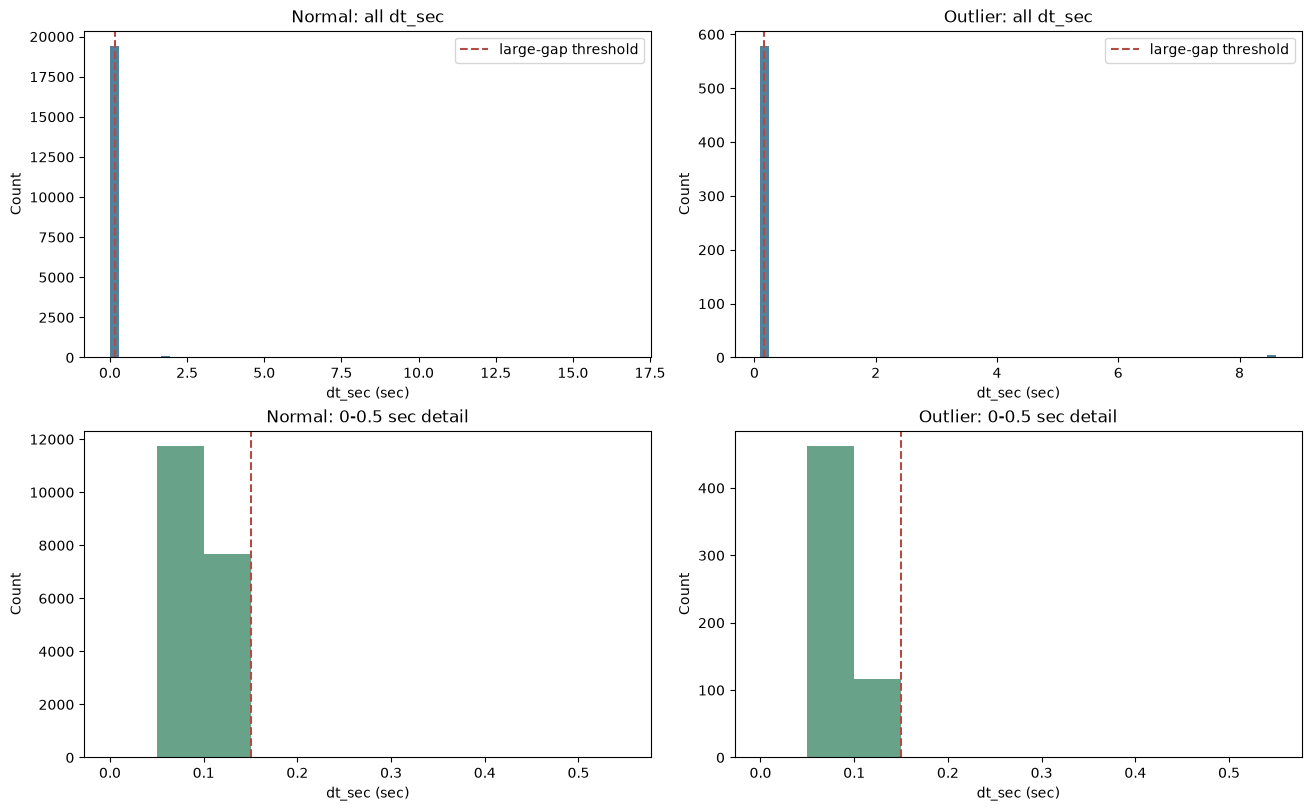

In [6]:
GAP_THRESHOLD_SEC = 0.15
GAP_DATASETS = {"Normal": normal, "Outlier": outlier}

def interval_summary(values):
    values = values.dropna()
    return pd.Series({
        "count": values.count(),
        "min": values.min(),
        "Q1": values.quantile(0.25),
        "median": values.median(),
        "mean": values.mean(),
        "Q3": values.quantile(0.75),
        "95%": values.quantile(0.95),
        "max": values.max(),
    })

all_dt_summary = pd.DataFrame({name: interval_summary(df["dt_sec"]) for name, df in GAP_DATASETS.items()}).T
print("All timestamp intervals (sec):")
display(all_dt_summary)

large_gap_summary = pd.DataFrame({
    name: interval_summary(df.loc[df["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False), "dt_sec"])
    for name, df in GAP_DATASETS.items()
}).T
print(f"Large gap intervals only (dt_sec > {GAP_THRESHOLD_SEC} sec):")
display(large_gap_summary)

for name, df in GAP_DATASETS.items():
    gaps = df.loc[df["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False), "dt_sec"]
    print(f"{name}: rounded gap value counts (0.1 sec resolution)")
    print(gaps.round(1).value_counts().sort_index().rename_axis("rounded_dt_sec").to_string())

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for col, (name, df) in enumerate(GAP_DATASETS.items()):
    dt_values = df["dt_sec"].dropna()
    axes[0, col].hist(dt_values, bins=60, color="#356a8a", alpha=0.85)
    axes[0, col].axvline(GAP_THRESHOLD_SEC, color="#b34b45", linestyle="--", label="large-gap threshold")
    axes[0, col].set(title=f"{name}: all dt_sec", xlabel="dt_sec (sec)", ylabel="Count")
    axes[0, col].legend()
    axes[1, col].hist(dt_values, bins=np.arange(0, 0.56, 0.05), color="#4d9274", alpha=0.85)
    axes[1, col].axvline(GAP_THRESHOLD_SEC, color="#b34b45", linestyle="--")
    axes[1, col].set(title=f"{name}: 0-0.5 sec detail", xlabel="dt_sec (sec)", ylabel="Count")
plt.show()

In [7]:
gap_position_tables = {}
for name, df in GAP_DATASETS.items():
    gap_mask = df["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False)
    gap_rows = df.loc[gap_mask, "source_row"].astype(int).to_numpy()
    row_distance = np.diff(gap_rows)
    table = pd.DataFrame({"gap_source_row": gap_rows})
    table["previous_gap_row_distance"] = np.r_[np.nan, row_distance]
    gap_position_tables[name] = table
    print(f"{name}: gap source rows and distance from previous gap")
    with pd.option_context("display.max_rows", None, "display.max_columns", None):
        display(table)
    print("Row-distance value counts:")
    display(pd.Series(row_distance, name="row_distance").value_counts().sort_index().to_frame())
    if len(row_distance):
        print(
            f"Median row distance={np.median(row_distance):.1f}; "
            f"exactly 50 rows={np.mean(row_distance == 50):.1%}; "
            f"within 45-55 rows={np.mean((row_distance >= 45) & (row_distance <= 55)):.1%}"
        )
        print("Gap source row modulo 50:")
        display(pd.Series(gap_rows % 50, name="source_row_mod_50").value_counts().sort_index().to_frame())

Normal: gap source rows and distance from previous gap


,gap_source_row,previous_gap_row_distance
0,41,NaN
1,78,37.0
2,102,24.0
3,112,10.0
4,162,50.0
5,212,50.0
6,262,50.0
7,303,41.0
8,329,26.0
9,342,13.0


Row-distance value counts:


,count
row_distance,
1,9
2,6
3,9
4,5
5,5
6,7
7,8
8,12
9,8


Median row distance=37.0; exactly 50 rows=33.8%; within 45-55 rows=39.5%
Gap source row modulo 50:


...

,gap_source_row,previous_gap_row_distance
0,4,NaN
1,54,50.0
2,101,47.0
3,132,31.0
4,150,18.0
5,153,3.0
6,203,50.0
7,243,40.0
8,268,25.0
9,276,8.0


Row-distance value counts:


,count
row_distance,
3,1
4,1
8,1
10,1
15,1
18,1
24,1
25,1
28,1


Median row distance=31.0; exactly 50 rows=26.3%; within 45-55 rows=31.6%
Gap source row modulo 50:


,count
source_row_mod_50,
0,2
1,2
3,2
4,2
15,3
18,1
22,1
25,1
26,1


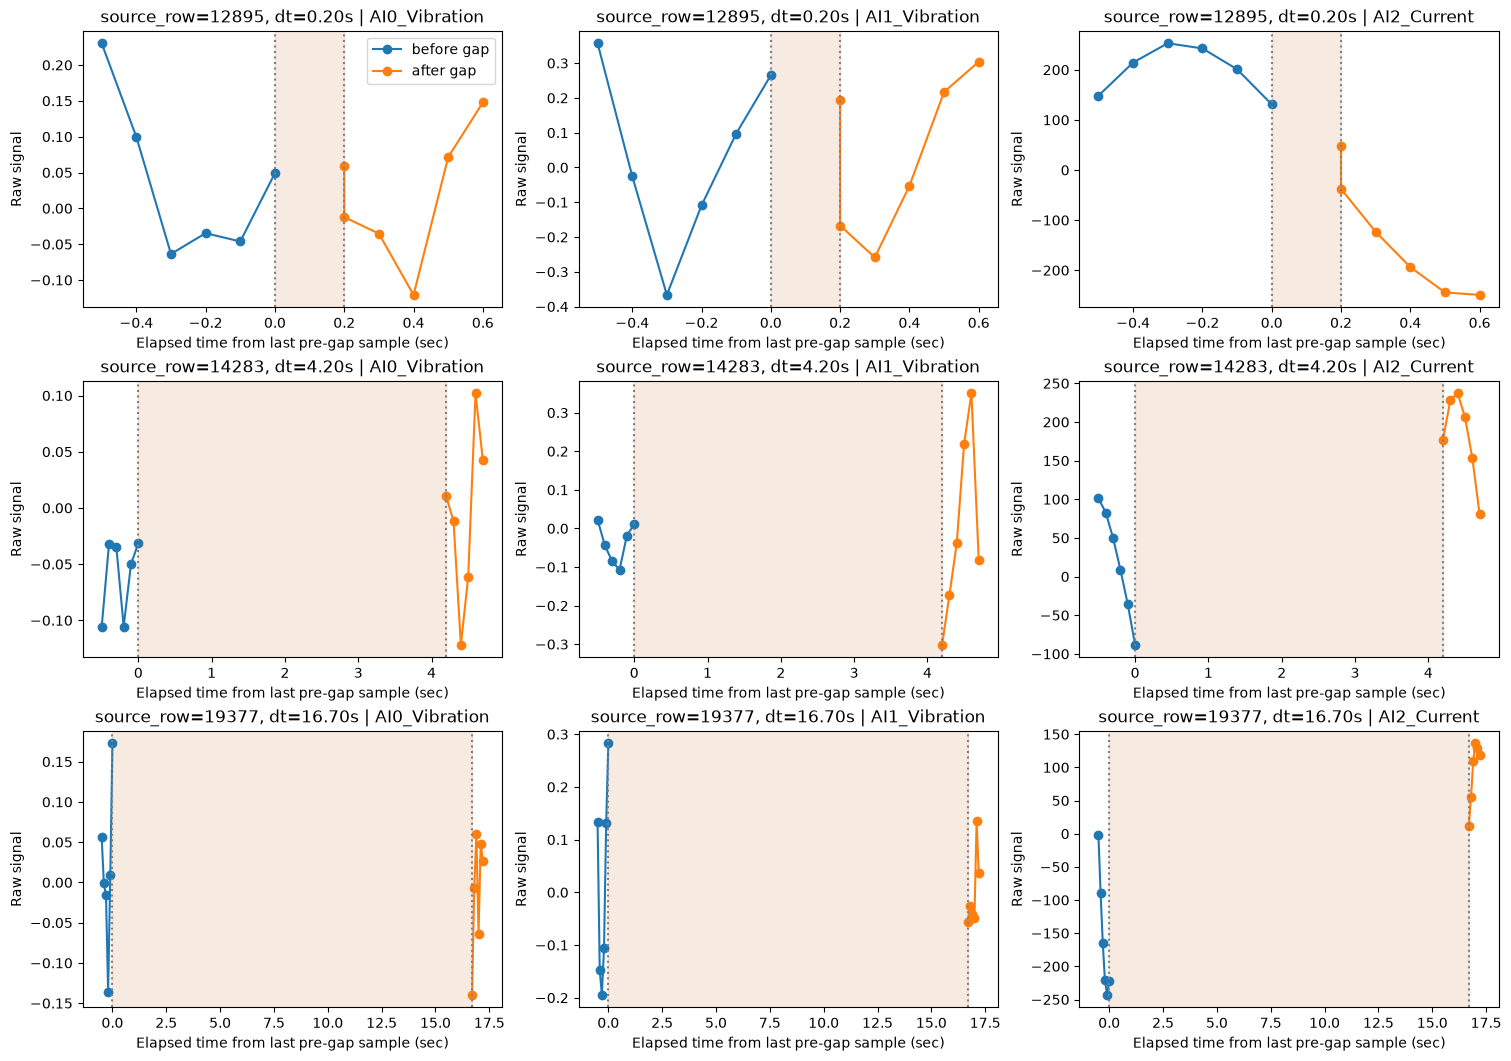

Gap windows show raw samples on both sides without drawing a line through the missing interval.


In [8]:
normal_gap_mask = normal["dt_sec"].gt(GAP_THRESHOLD_SEC).fillna(False)
normal_gap_rows = np.flatnonzero(normal_gap_mask.to_numpy(dtype=bool))
if len(normal_gap_rows):
    normal_gap_durations = normal.loc[normal_gap_mask, "dt_sec"]
    target_values = [normal_gap_durations.min(), normal_gap_durations.median(), normal_gap_durations.max()]
    selected_gap_positions = []
    for target in target_values:
        candidate = int(np.argmin(np.abs(normal_gap_durations.to_numpy() - target)))
        if candidate not in selected_gap_positions:
            selected_gap_positions.append(candidate)

    fig, axes = plt.subplots(len(selected_gap_positions), len(CHANNELS), figsize=(15, 3.5 * len(selected_gap_positions)), squeeze=False, constrained_layout=True)
    normal_gap_index = np.flatnonzero(normal_gap_mask.to_numpy(dtype=bool))
    for row_plot, gap_number in enumerate(selected_gap_positions):
        idx = int(normal_gap_index[gap_number])
        gap = normal.iloc[idx]
        left = normal.iloc[max(0, idx - 6):idx]
        right = normal.iloc[idx:min(len(normal), idx + 6)]
        gap_start_time = float(normal.iloc[idx - 1]["elapsed_sec"])
        gap_end_time = float(gap["elapsed_sec"])
        for col_plot, channel in enumerate(CHANNELS):
            ax = axes[row_plot, col_plot]
            ax.plot(left["elapsed_sec"] - gap_start_time, left[channel], "o-", label="before gap")
            ax.plot(right["elapsed_sec"] - gap_start_time, right[channel], "o-", label="after gap")
            ax.axvspan(0, gap_end_time - gap_start_time, color="#d88b57", alpha=0.18)
            ax.axvline(0, color="gray", linestyle=":")
            ax.axvline(gap_end_time - gap_start_time, color="gray", linestyle=":")
            ax.set_title(f"source_row={int(gap['source_row'])}, dt={gap['dt_sec']:.2f}s | {channel}")
            ax.set_xlabel("Elapsed time from last pre-gap sample (sec)")
            ax.set_ylabel("Raw signal")
            if row_plot == 0 and col_plot == 0:
                ax.legend()
    plt.show()
    print("Gap windows show raw samples on both sides without drawing a line through the missing interval.")

### Gap 구조 결론

**C. 두 가능성이 혼재함.** Normal의 599개 large gap은 중앙값 4.20초(Q1 2.40초, 평균 4.47초, 최댓값 16.7초)로 단순한 0.1초 sampling 흔들림이 아니다. 이전 gap과의 row distance는 중앙값 37행이고, 598개 거리 중 202개(33.8%)가 정확히 50행이며 39.5%가 45-55행 범위여서 반복되는 block 경계 흔적이 있다. 동시에 나머지 간격과 gap 길이는 넓게 분포한다. Outlier도 20개 gap의 중앙값이 5.35초이며 row-distance 규칙이 Normal보다 약하다. 신호 전후 그래프는 개별 지점의 연속/상태 변화 단서를 보여주지만 운전 정지와 누락을 확정적으로 분리하지 못한다. 따라서 block 구조와 실제 운전 단절/데이터 누락 가능성이 함께 있으며, 수집기·PLC 로그 없이는 원인을 단정하지 않는다.

## ② Outlier Cycle Candidate 부족 원인 검증

기존 adaptive detector를 segment별로 재현하고, 길이 제외·AI2 변동성·prominence·peak 수를 분리해 본다. 그 뒤 Normal segment에서 산출한 prominence 중앙값을 고정 비교값으로 정해 Outlier에 그대로 적용한다. 고정 threshold 결과는 peak 수 자체가 아니라 파형 위치와 cycle duration까지 검토한다.

Normal: segment-level detector diagnostics (all segments)


,dataset,segment_id,n_samples,AI2_std,current_prominence,peak_count,candidate_cycle_count,eligible_by_length
0,Normal,0,1,0.000000,2.220446e-16,0,0,False
1,Normal,1,40,146.457596,7.322880e+01,2,1,True
2,Normal,2,37,138.820529,6.941026e+01,2,1,True
3,Normal,3,24,79.872493,3.993625e+01,0,0,False
4,Normal,4,10,160.583249,8.029162e+01,0,0,False
...,...,...,...,...,...,...,...,...
598,Normal,598,35,180.948540,9.047427e+01,2,1,True
599,Normal,599,22,99.151659,4.957583e+01,0,0,False
600,Normal,600,8,82.881629,4.144081e+01,0,0,False
601,Normal,601,50,148.550283,7.427514e+01,3,2,True


Normal: eligible segment counts; segments shorter than 30 are skipped by the existing detector


,count,mean,std,min,25%,50%,75%,max
AI2_std,360.0,116.288351,36.125180,76.161906,84.922561,99.234189,148.728058,184.84142
current_prominence,360.0,58.144175,18.062590,38.080953,42.461280,49.617095,74.364029,92.42071
peak_count,360.0,2.319444,0.583582,1.000000,2.000000,2.000000,3.000000,3.00000


Outlier: segment-level detector diagnostics (all segments)


...

,count,mean,std,min,25%,50%,75%,max
AI2_std,10.0,86.652389,32.354462,29.831217,64.055894,93.461301,113.121077,124.419894
current_prominence,10.0,43.326194,16.177231,14.915609,32.027947,46.730651,56.560539,62.209947
peak_count,10.0,1.800000,0.788811,1.000000,1.000000,2.000000,2.000000,3.000000


Outlier eligible segment counts by peak group:


,segment_count
peak_group,
peak 0,0
peak 1,4
peak 2+,6


Outlier eligible segment details:


,segment_id,n_samples,AI2_std,current_prominence,peak_count
2,2,50,73.181365,36.590682,3
3,3,47,93.389581,46.694791,1
4,4,31,29.831217,14.915609,1
7,7,50,111.125299,55.562649,2
8,8,40,124.419894,62.209947,1
12,12,50,47.946004,23.973002,3
13,13,42,61.014071,30.507035,2
16,16,50,118.297100,59.148550,1
17,17,50,93.533021,46.766511,2
18,18,36,113.786337,56.893168,2


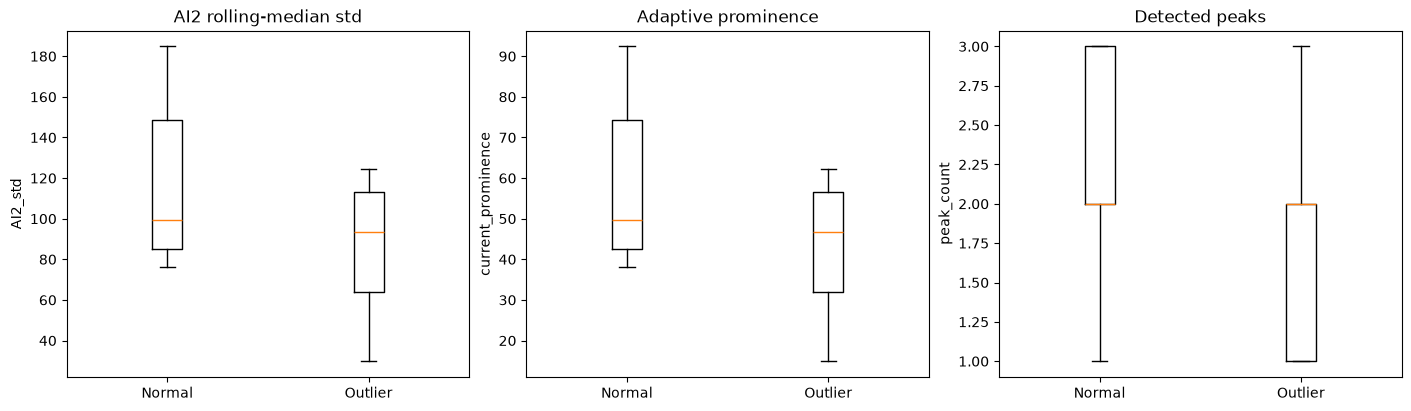

In [9]:
def segment_peak_diagnostics(df, dataset_name):
    rows = []
    for segment_id, group in df.groupby("segment_id", sort=False):
        values = group[CYCLE_ANCHOR].to_numpy(dtype=float)
        smooth = pd.Series(values).rolling(3, center=True, min_periods=1).median()
        ai2_std = float(smooth.std()) if len(smooth) > 1 else 0.0
        prominence = max(ai2_std * 0.5, np.finfo(float).eps)
        eligible = len(group) >= MIN_SEGMENT_ROWS and np.isfinite(values).all()
        peaks = find_peaks(
            smooth.to_numpy(), distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES,
            prominence=prominence,
        )[0] if eligible else np.array([], dtype=int)
        rows.append({
            "dataset": dataset_name,
            "segment_id": int(segment_id),
            "n_samples": len(group),
            "AI2_std": ai2_std,
            "current_prominence": prominence,
            "peak_count": len(peaks),
            "candidate_cycle_count": max(len(peaks) - 1, 0),
            "eligible_by_length": eligible,
        })
    return pd.DataFrame(rows)

normal_segment_diagnostics = segment_peak_diagnostics(normal, "Normal")
outlier_segment_diagnostics = segment_peak_diagnostics(outlier, "Outlier")
segment_diagnostics = pd.concat([normal_segment_diagnostics, outlier_segment_diagnostics], ignore_index=True)

for name, diagnostics in [("Normal", normal_segment_diagnostics), ("Outlier", outlier_segment_diagnostics)]:
    print(f"{name}: segment-level detector diagnostics (all segments)")
    display(diagnostics)
    eligible = diagnostics.loc[diagnostics["eligible_by_length"]]
    print(f"{name}: eligible segment counts; segments shorter than {MIN_SEGMENT_ROWS} are skipped by the existing detector")
    display(eligible[["AI2_std", "current_prominence", "peak_count"]].describe().T)

outlier_eligible = outlier_segment_diagnostics.loc[outlier_segment_diagnostics["eligible_by_length"]].copy()
outlier_eligible["peak_group"] = pd.cut(
    outlier_eligible["peak_count"], bins=[-1, 0, 1, np.inf], labels=["peak 0", "peak 1", "peak 2+"],
)
print("Outlier eligible segment counts by peak group:")
display(outlier_eligible["peak_group"].value_counts().reindex(["peak 0", "peak 1", "peak 2+"], fill_value=0).rename("segment_count").to_frame())
print("Outlier eligible segment details:")
display(outlier_eligible[["segment_id", "n_samples", "AI2_std", "current_prominence", "peak_count"]])

fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for ax, metric, title in zip(axes, ["AI2_std", "current_prominence", "peak_count"], ["AI2 rolling-median std", "Adaptive prominence", "Detected peaks"]):
    plot_data = [
        normal_segment_diagnostics.loc[normal_segment_diagnostics["eligible_by_length"], metric],
        outlier_segment_diagnostics.loc[outlier_segment_diagnostics["eligible_by_length"], metric],
    ]
    ax.boxplot(plot_data, tick_labels=["Normal", "Outlier"], showfliers=True)
    ax.set_title(title)
    ax.set_ylabel(metric)
plt.show()

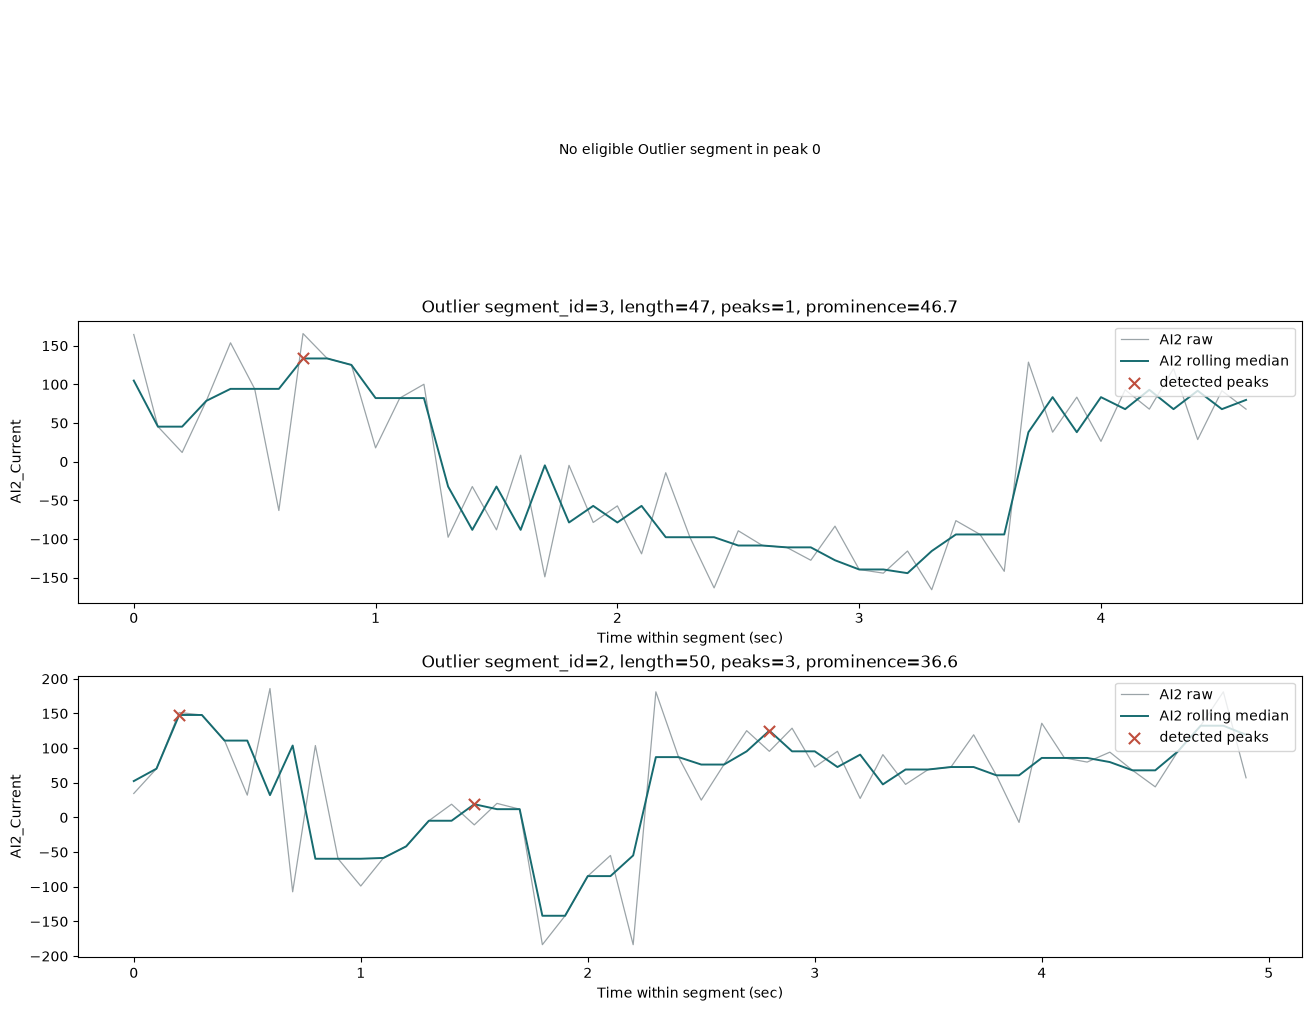

In [10]:
peak_categories = [("peak 0", 0), ("peak 1", 1), ("peak 2+", 2)]
fig, axes = plt.subplots(len(peak_categories), 1, figsize=(13, 10), squeeze=False, constrained_layout=True)
for row_plot, (category, minimum_peaks) in enumerate(peak_categories):
    ax = axes[row_plot, 0]
    candidates = outlier_eligible.loc[outlier_eligible["peak_group"] == category]
    if candidates.empty:
        ax.text(0.5, 0.5, f"No eligible Outlier segment in {category}", ha="center", va="center")
        ax.set_axis_off()
        continue
    target_std = candidates["AI2_std"].median()
    chosen = candidates.iloc[(candidates["AI2_std"] - target_std).abs().argsort()[:1]]
    segment_id = int(chosen.iloc[0]["segment_id"])
    group = outlier.loc[outlier["segment_id"] == segment_id]
    raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
    smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
    threshold = float(chosen.iloc[0]["current_prominence"])
    peaks = find_peaks(smooth, distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES, prominence=threshold)[0]
    time = np.arange(len(group)) / SAMPLE_RATE_HZ
    ax.plot(time, raw, color="#9ba4a8", linewidth=0.9, label="AI2 raw")
    ax.plot(time, smooth, color="#176b70", linewidth=1.4, label="AI2 rolling median")
    ax.scatter(time[peaks], smooth[peaks], color="#bf4e3d", marker="x", s=65, label="detected peaks", zorder=3)
    ax.set_title(f"Outlier segment_id={segment_id}, length={len(group)}, peaks={len(peaks)}, prominence={threshold:.3g}")
    ax.set_xlabel("Time within segment (sec)")
    ax.set_ylabel("AI2_Current")
    ax.legend(loc="upper right")
plt.show()

In [11]:
FIXED_NORMAL_PROMINENCE = float(
    normal_segment_diagnostics.loc[normal_segment_diagnostics["eligible_by_length"], "current_prominence"].median()
)
print(
    "Frozen threshold rationale: median of per-segment Normal adaptive prominence "
    f"across eligible Normal segments = {FIXED_NORMAL_PROMINENCE:.6g} AI2 units."
)

def detect_peak_method(df, dataset_name, method_name, fixed_prominence=None):
    summary_rows = []
    duration_rows = []
    peak_locations = {}
    for segment_id, group in df.groupby("segment_id", sort=False):
        if len(group) < MIN_SEGMENT_ROWS:
            continue
        raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
        if not np.isfinite(raw).all():
            continue
        smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
        threshold = (
            max(float(pd.Series(smooth).std()) * 0.5, np.finfo(float).eps)
            if fixed_prominence is None else fixed_prominence
        )
        peaks = find_peaks(smooth, distance=CYCLE_MIN_PEAK_DISTANCE_SAMPLES, prominence=threshold)[0]
        peak_locations[(dataset_name, int(segment_id), method_name)] = peaks
        durations = np.diff(group["elapsed_sec"].to_numpy()[peaks]) if len(peaks) > 1 else np.array([])
        summary_rows.append({
            "dataset": dataset_name,
            "method": method_name,
            "segment_id": int(segment_id),
            "peak_count": len(peaks),
            "candidate_cycle_count": max(len(peaks) - 1, 0),
        })
        duration_rows.extend({
            "dataset": dataset_name, "method": method_name, "segment_id": int(segment_id),
            "duration_sec": float(duration),
        } for duration in durations if duration > 0)
    return pd.DataFrame(summary_rows), pd.DataFrame(duration_rows), peak_locations

method_summaries = []
method_durations = []
method_peak_locations = {}
for dataset_name, df in [("Normal", normal), ("Outlier", outlier)]:
    for method_name, fixed_value in [("Current adaptive", None), ("Fixed Normal-derived", FIXED_NORMAL_PROMINENCE)]:
        summary, durations, locations = detect_peak_method(df, dataset_name, method_name, fixed_value)
        method_summaries.append(summary)
        method_durations.append(durations)
        method_peak_locations.update(locations)
method_summary = pd.concat(method_summaries, ignore_index=True)
method_duration_table = pd.concat(method_durations, ignore_index=True)

comparison_counts = method_summary.groupby(["dataset", "method"])[["peak_count", "candidate_cycle_count"]].sum().rename(columns={
    "peak_count": "total_peaks", "candidate_cycle_count": "total_candidate_cycles",
})
print("Adaptive vs Normal-derived fixed threshold: total peaks and peak-to-peak cycles")
display(comparison_counts)

def duration_stats(values):
    values = pd.Series(values, dtype=float)
    return pd.Series({
        "count": values.count(), "mean": values.mean(), "std": values.std(),
        "min": values.min(), "Q1": values.quantile(.25), "median": values.median(),
        "Q3": values.quantile(.75), "max": values.max(),
    })
print("Cycle duration distributions by dataset and detector:")
display(method_duration_table.groupby(["dataset", "method"])["duration_sec"].apply(duration_stats).unstack())

Frozen threshold rationale: median of per-segment Normal adaptive prominence across eligible Normal segments = 49.6171 AI2 units.


Adaptive vs Normal-derived fixed threshold: total peaks and peak-to-peak cycles


total_peaks  total_candidate_cycles
dataset method                                                   
Normal  Current adaptive              835                     475
        Fixed Normal-derived          844                     484
Outlier Current adaptive               18                       8
        Fixed Normal-derived           18                       8

Cycle duration distributions by dataset and detector:


count      mean       std  min   Q1  median  \
dataset method                                                              
Normal  Current adaptive      475.0  1.667368  0.046936  1.6  1.6    1.70   
        Fixed Normal-derived  484.0  1.667769  0.046785  1.6  1.6    1.70   
Outlier Current adaptive        8.0  1.500000  0.226779  1.2  1.3    1.55   
        Fixed Normal-derived    8.0  1.575000  0.406202  1.2  1.3    1.55   

                               Q3  max  
dataset method                          
Normal  Current adaptive      1.7  1.7  
        Fixed Normal-derived  1.7  1.7  
Outlier Current adaptive      1.6  1.9  
        Fixed Normal-derived  1.6  2.5

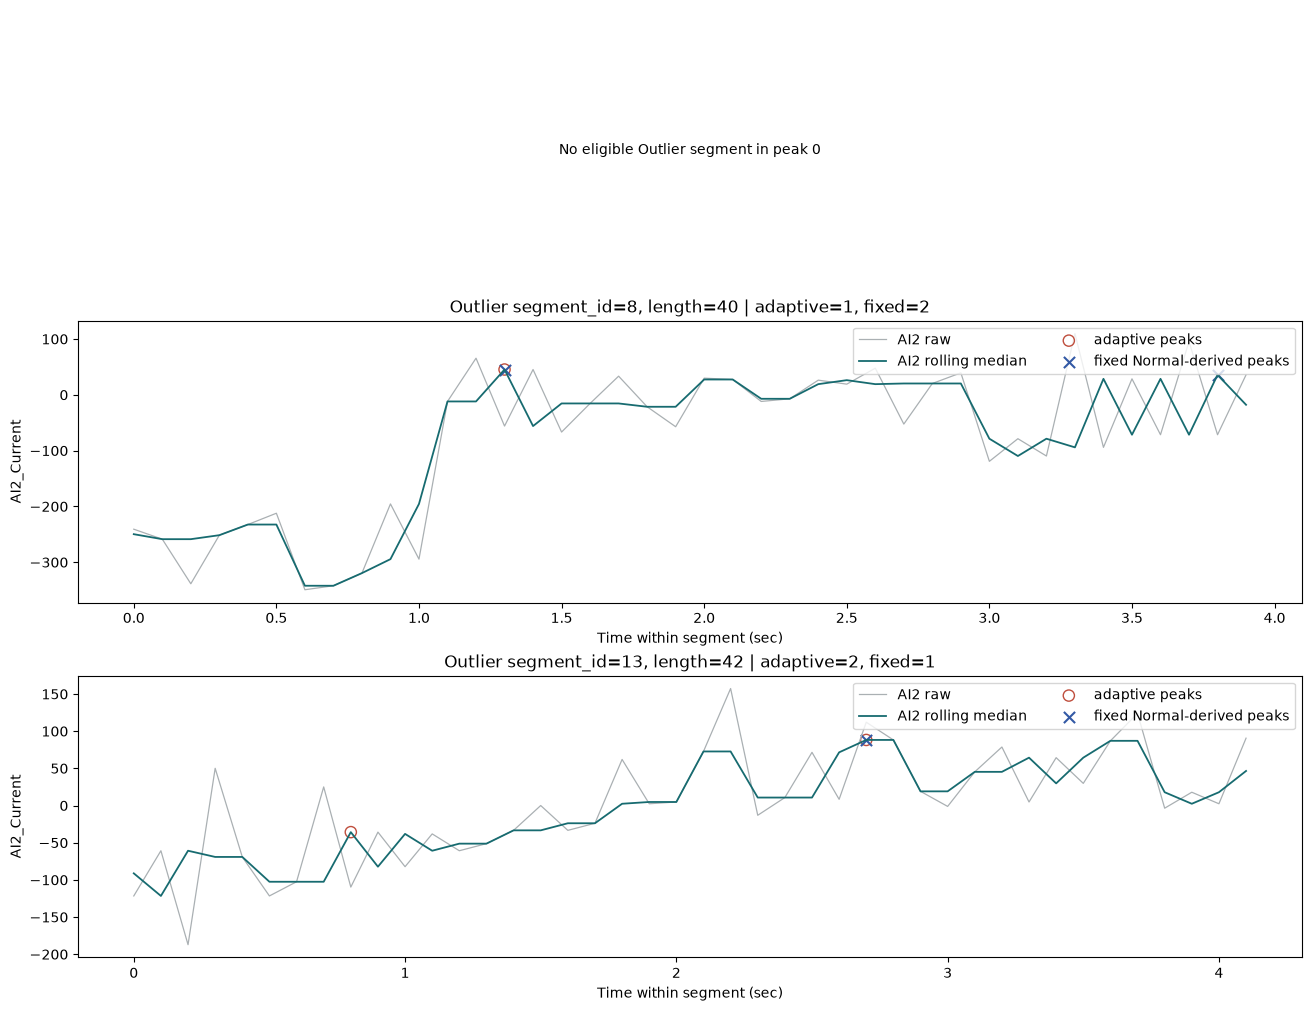

Peak-count increases under a fixed threshold are not treated as evidence of a better cycle detector; inspect alignment to visible waveform structure.


In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), squeeze=False, constrained_layout=True)
for row_plot, (category, _) in enumerate(peak_categories):
    ax = axes[row_plot, 0]
    candidates = outlier_eligible.loc[outlier_eligible["peak_group"] == category]
    if candidates.empty:
        ax.text(0.5, 0.5, f"No eligible Outlier segment in {category}", ha="center", va="center")
        ax.set_axis_off()
        continue
    chosen_id = int(candidates.sort_values("segment_id").iloc[len(candidates) // 2]["segment_id"])
    group = outlier.loc[outlier["segment_id"] == chosen_id]
    raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
    smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
    adaptive = method_peak_locations[("Outlier", chosen_id, "Current adaptive")]
    fixed = method_peak_locations[("Outlier", chosen_id, "Fixed Normal-derived")]
    time = np.arange(len(group)) / SAMPLE_RATE_HZ
    ax.plot(time, raw, color="#aab0b3", linewidth=0.9, label="AI2 raw")
    ax.plot(time, smooth, color="#176b70", linewidth=1.3, label="AI2 rolling median")
    ax.scatter(time[adaptive], smooth[adaptive], marker="o", facecolors="none", edgecolors="#bf4e3d", s=65, label="adaptive peaks")
    ax.scatter(time[fixed], smooth[fixed], marker="x", color="#3359a5", s=65, label="fixed Normal-derived peaks")
    ax.set_title(f"Outlier segment_id={chosen_id}, length={len(group)} | adaptive={len(adaptive)}, fixed={len(fixed)}")
    ax.set_xlabel("Time within segment (sec)")
    ax.set_ylabel("AI2_Current")
    ax.legend(loc="upper right", ncol=2)
plt.show()
print("Peak-count increases under a fixed threshold are not treated as evidence of a better cycle detector; inspect alignment to visible waveform structure.")

## ③ Normal AI2 1.6-1.7초 Cycle Candidate 반복성 검증

여러 Normal segment에서 raw 신호와 peak-to-peak 경계를 확인하고, 전체 candidate duration의 분포를 평가한다. 이후 cycle 길이 차이 비교를 위한 phase 정렬을 사용해 overlay, median/IQR template, Normal 내부 shape consistency를 계산한다. 이는 실제 Press Cycle의 물리적 확정이나 분류 성능 평가가 아니다.

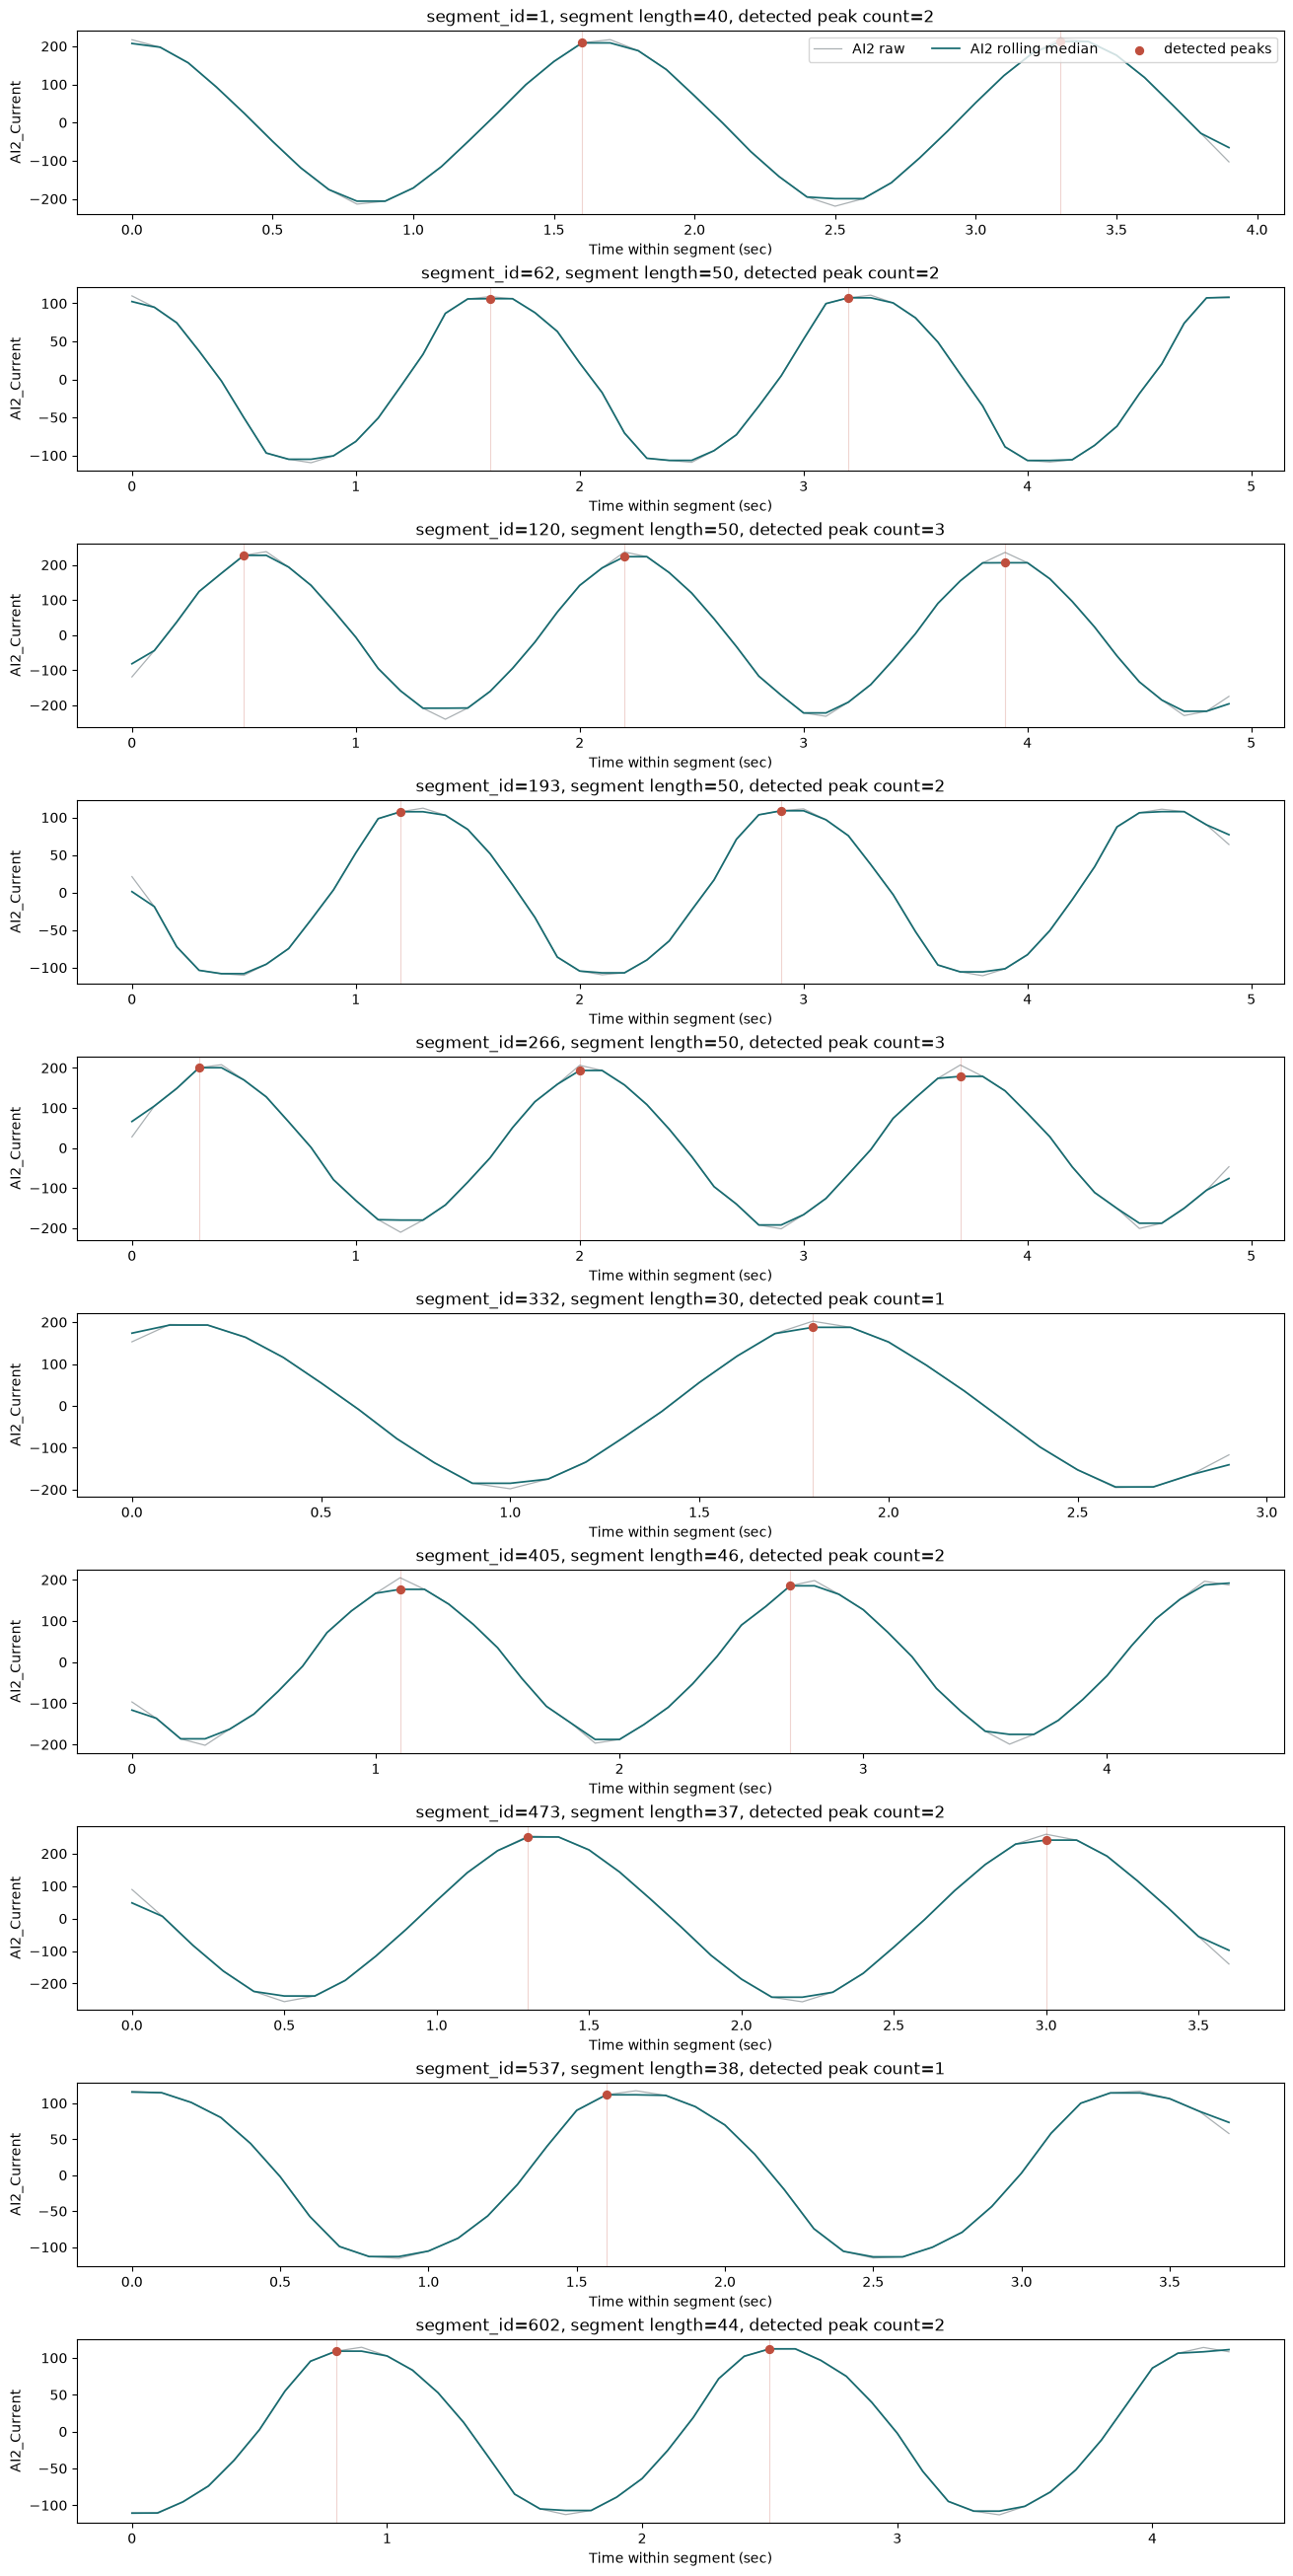

Displayed 10 distinct eligible Normal segments; vertical lines mark peak-to-peak candidate boundaries.


In [13]:
eligible_normal = normal_segment_diagnostics.loc[normal_segment_diagnostics["eligible_by_length"], "segment_id"].astype(int).to_numpy()
selected_normal_segments = np.unique(np.linspace(0, len(eligible_normal) - 1, min(10, len(eligible_normal)), dtype=int))
selected_normal_segments = eligible_normal[selected_normal_segments]
fig, axes = plt.subplots(len(selected_normal_segments), 1, figsize=(13, 2.6 * len(selected_normal_segments)), squeeze=False, constrained_layout=True)
for row_plot, segment_id in enumerate(selected_normal_segments):
    ax = axes[row_plot, 0]
    group = normal.loc[normal["segment_id"] == segment_id]
    raw = group[CYCLE_ANCHOR].to_numpy(dtype=float)
    smooth = pd.Series(raw).rolling(3, center=True, min_periods=1).median().to_numpy()
    peaks = method_peak_locations[("Normal", int(segment_id), "Current adaptive")]
    time = np.arange(len(group)) / SAMPLE_RATE_HZ
    ax.plot(time, raw, color="#aab0b3", linewidth=0.9, label="AI2 raw")
    ax.plot(time, smooth, color="#176b70", linewidth=1.25, label="AI2 rolling median")
    ax.scatter(time[peaks], smooth[peaks], color="#bf4e3d", marker="o", s=32, label="detected peaks", zorder=3)
    for boundary in peaks:
        ax.axvline(time[boundary], color="#bf4e3d", alpha=0.24, linewidth=0.8)
    ax.set_title(f"segment_id={int(segment_id)}, segment length={len(group)}, detected peak count={len(peaks)}")
    ax.set_xlabel("Time within segment (sec)")
    ax.set_ylabel("AI2_Current")
    if row_plot == 0:
        ax.legend(loc="upper right", ncol=3)
plt.show()
print(f"Displayed {len(selected_normal_segments)} distinct eligible Normal segments; vertical lines mark peak-to-peak candidate boundaries.")

,Normal candidate duration
count,475.000000
mean,1.667368
std,0.046936
min,1.600000
Q1,1.600000
median,1.700000
Q3,1.700000
max,1.700000
CV_std_over_mean,0.028150
fraction_rounded_0.1s_in_1.6_to_1.7_sec,1.000000


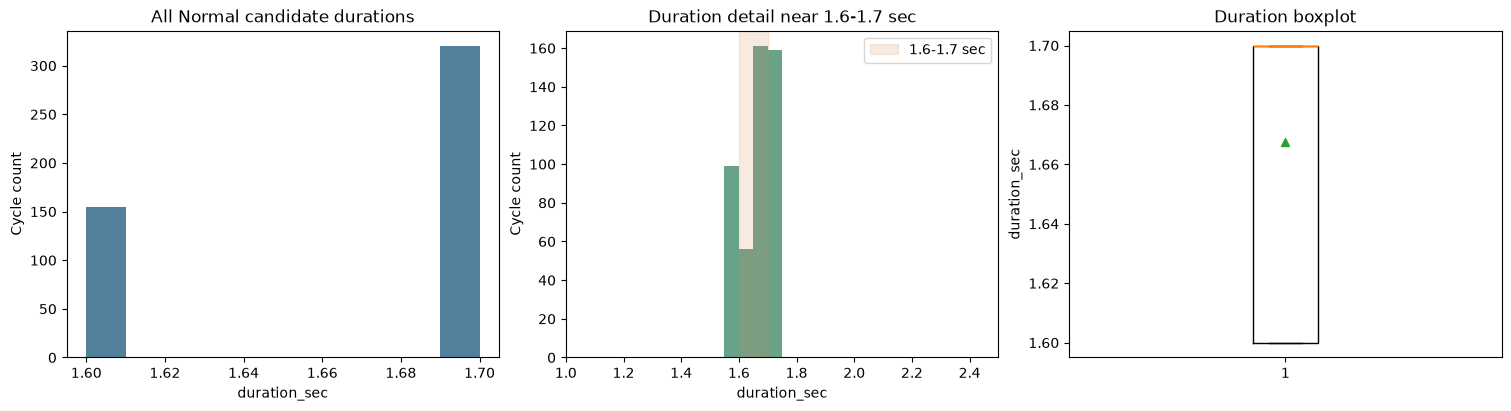

In [14]:
normal_durations = cycle_features["duration_sec"].dropna().astype(float)
normal_duration_summary = pd.Series({
    "count": normal_durations.count(),
    "mean": normal_durations.mean(),
    "std": normal_durations.std(),
    "min": normal_durations.min(),
    "Q1": normal_durations.quantile(.25),
    "median": normal_durations.median(),
    "Q3": normal_durations.quantile(.75),
    "max": normal_durations.max(),
    "CV_std_over_mean": normal_durations.std() / normal_durations.mean(),
    "fraction_rounded_0.1s_in_1.6_to_1.7_sec": normal_durations.round(1).between(1.6, 1.7, inclusive="both").mean(),
}, name="Normal candidate duration")
display(normal_duration_summary.to_frame())

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
axes[0].hist(normal_durations, bins="auto", color="#356a8a", alpha=0.85)
axes[0].set(title="All Normal candidate durations", xlabel="duration_sec", ylabel="Cycle count")
axes[1].hist(normal_durations, bins=np.arange(1.0, 2.51, 0.05), color="#4d9274", alpha=0.85)
axes[1].axvspan(1.6, 1.7, color="#d88b57", alpha=0.18, label="1.6-1.7 sec")
axes[1].set_xlim(1.0, 2.5)
axes[1].set(title="Duration detail near 1.6-1.7 sec", xlabel="duration_sec", ylabel="Cycle count")
axes[1].legend()
axes[2].boxplot(normal_durations, showmeans=True)
axes[2].set(title="Duration boxplot", ylabel="duration_sec")
plt.show()

### Phase 정렬 해석

각 cycle을 0-100% phase의 공통 grid로 선형 interpolation해 길이를 비교한다. 이는 cycle 길이 차이를 비교하기 위한 **재표현**이며, 측정되지 않은 시간 구간의 물리 신호를 새로 관측하거나 원본 10 Hz 정보를 증가시키지 않는다. 원본 raw 채널 및 gap은 변경하지 않는다.

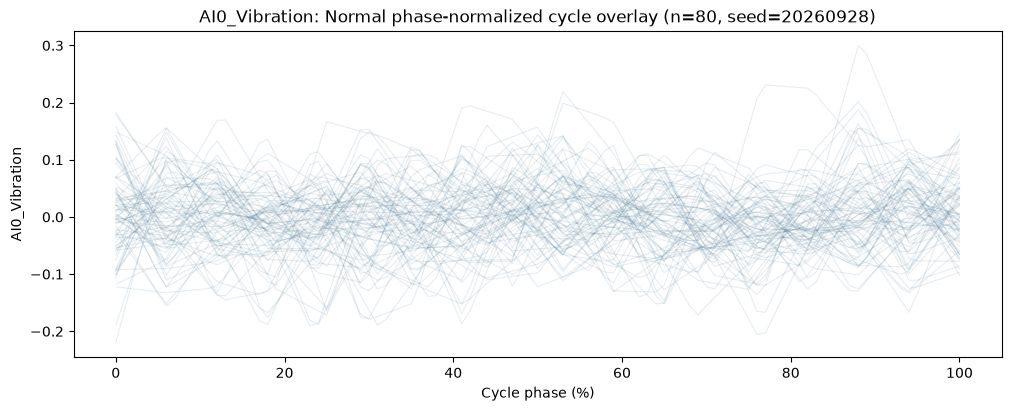

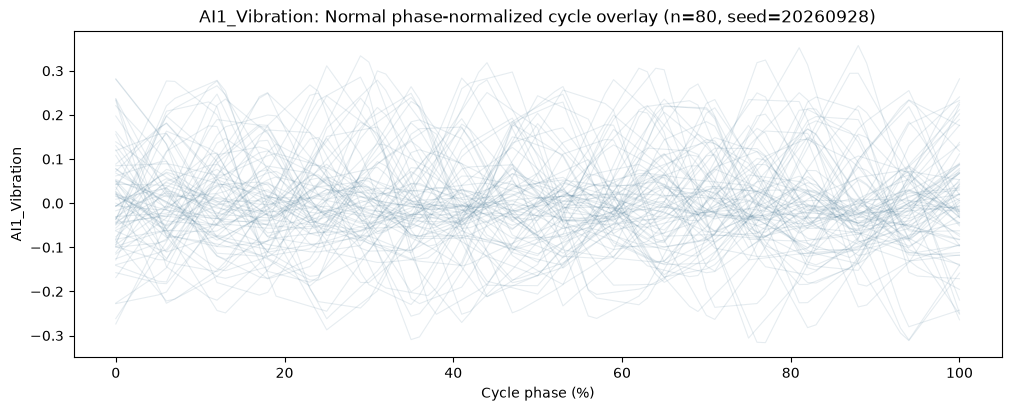

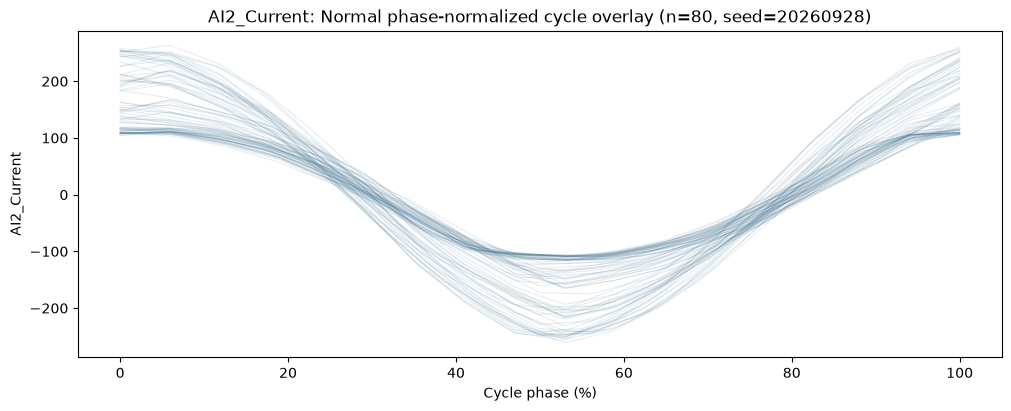

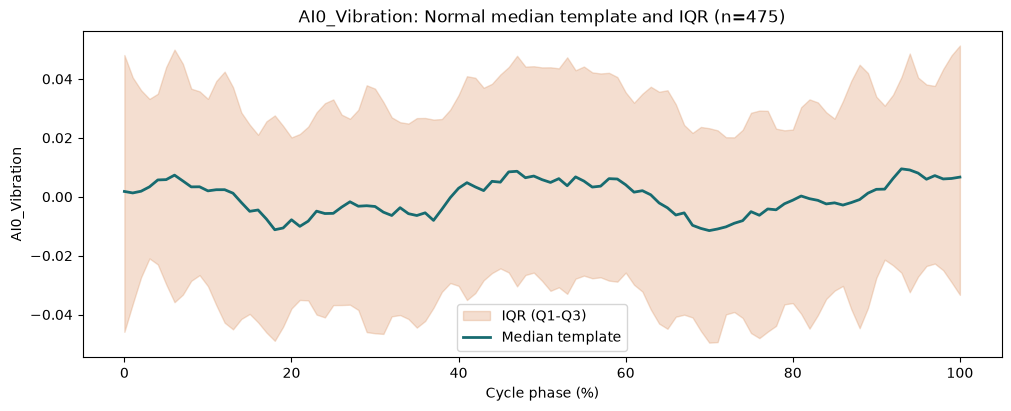

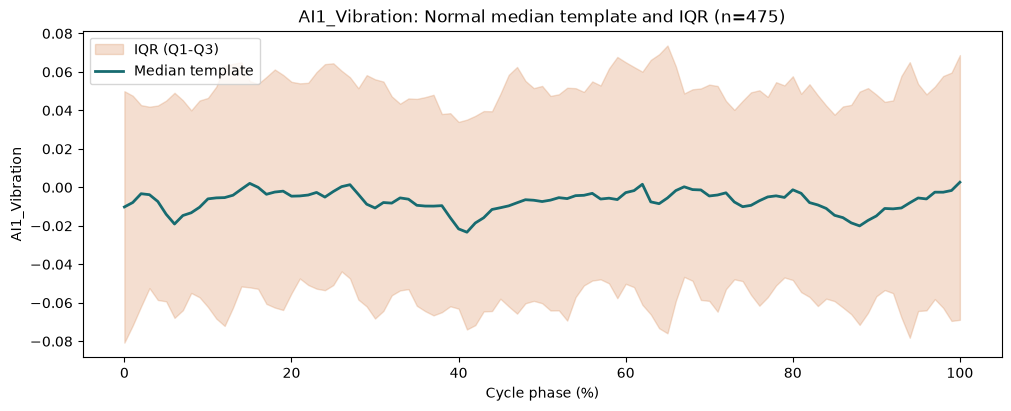

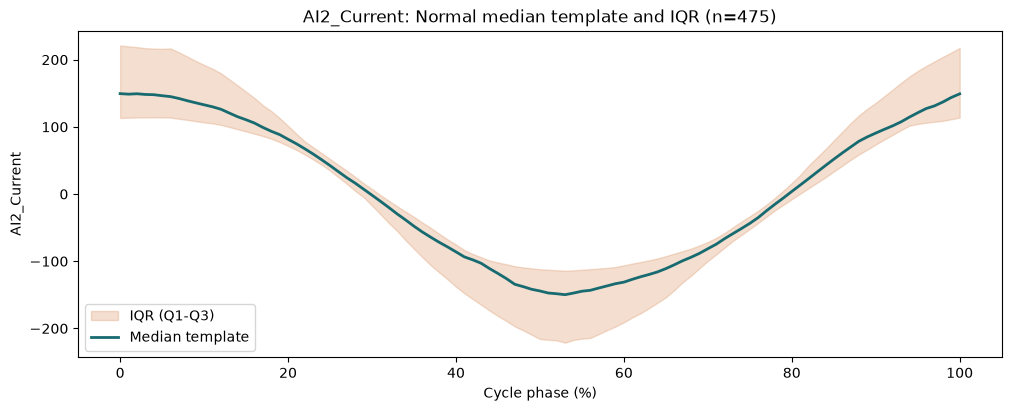

Normal cycle-internal shape consistency (EDA only; not classification performance):


RMSE_to_median_template                                   \
                                count       mean     median        std   
channel                                                                  
AI0_Vibration                     475   0.054241   0.053097   0.018999   
AI1_Vibration                     475   0.091143   0.079738   0.053551   
AI2_Current                       475  34.359708  24.194145  21.728585   

                                   correlation_to_median_template            \
                    min        max                          count      mean   
channel                                                                       
AI0_Vibration  0.016724   0.145157                            475  0.103222   
AI1_Vibration  0.020248   0.202622                            475  0.056828   
AI2_Current    4.410524  84.686900                            475  0.994940   

                                                       
                 median       std       min       max  
channel                                                
AI0_Vibration  0.139027  0.323516 -0.771237  0.831727  
AI1_Vibration  0.070420  0.228241 -0.596515  0.607888  
AI2_Current    0.996505  0.004384  0.968304  0.999648

In [15]:
waveforms_by_channel = {
    channel: {
        (item["segment_id"], item["cycle_number_in_segment"]): item["values"]
        for item in cycle_waveforms if item["channel"] == channel
    }
    for channel in CHANNELS
}
cycle_keys = sorted(waveforms_by_channel[CYCLE_ANCHOR])
overlay_rng = np.random.default_rng(20260928)
overlay_count = min(80, len(cycle_keys))
overlay_keys = sorted(overlay_rng.choice(len(cycle_keys), size=overlay_count, replace=False).tolist())
overlay_cycle_keys = [cycle_keys[index] for index in overlay_keys]
phase_percent = np.linspace(0, 100, TEMPLATE_PHASE_POINTS)

for channel in CHANNELS:
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    for key in overlay_cycle_keys:
        ax.plot(phase_percent, waveforms_by_channel[channel][key], color="#356a8a", alpha=0.12, linewidth=0.8)
    ax.set(title=f"{channel}: Normal phase-normalized cycle overlay (n={overlay_count}, seed=20260928)", xlabel="Cycle phase (%)", ylabel=channel)
    plt.show()

cycle_shape_metrics = []
for channel in CHANNELS:
    matrix = np.vstack([waveforms_by_channel[channel][key] for key in cycle_keys])
    q1 = np.quantile(matrix, 0.25, axis=0)
    median = np.median(matrix, axis=0)
    q3 = np.quantile(matrix, 0.75, axis=0)
    fig, ax = plt.subplots(figsize=(10, 4), constrained_layout=True)
    ax.fill_between(phase_percent, q1, q3, color="#d88b57", alpha=0.28, label="IQR (Q1-Q3)")
    ax.plot(phase_percent, median, color="#176b70", linewidth=2, label="Median template")
    ax.set(title=f"{channel}: Normal median template and IQR (n={len(matrix)})", xlabel="Cycle phase (%)", ylabel=channel)
    ax.legend()
    plt.show()

    for key, values in zip(cycle_keys, matrix):
        template_rmse = float(np.sqrt(np.mean(np.square(values - median))))
        correlation = float(np.corrcoef(values, median)[0, 1]) if np.std(values) > 0 and np.std(median) > 0 else np.nan
        cycle_shape_metrics.append({
            "channel": channel,
            "segment_id": key[0],
            "cycle_number_in_segment": key[1],
            "RMSE_to_median_template": template_rmse,
            "correlation_to_median_template": correlation,
        })

cycle_shape_metrics = pd.DataFrame(cycle_shape_metrics)
print("Normal cycle-internal shape consistency (EDA only; not classification performance):")
display(cycle_shape_metrics.groupby("channel")[["RMSE_to_median_template", "correlation_to_median_template"]].agg(["count", "mean", "median", "std", "min", "max"]))

## 최종 판단

| 검증 질문 | 핵심 결과 | 현재 판단 | 다음 조치 |
|---|---|---|---|
| 599 large gap의 구조 | Normal gap 599개, 중앙값 4.20초; 598개 row distance 중 202개(33.8%)가 50행, 중앙 row distance 37행 | **C. 두 가능성이 혼재함.** 반복 block 흔적과 불규칙한 장시간 공백이 함께 있으나 실제 정지·누락은 확정 불가 | 수집기 저장 규칙과 PLC 운전 상태·정지 로그를 대조 |
| Outlier cycle 8개 원인 | 22개 중 12개 segment가 30 samples 미만으로 기존 detector 제외; eligible 10개 중 4개는 peak 1개, 6개는 2개 이상. Adaptive와 fixed Normal prominence(49.617) 모두 18 peaks/8 cycles | segment 길이와 segment당 peak 부족이 주된 제약으로 보이며, adaptive prominence 차이만으로 설명되지 않음. Fixed 방식의 Outlier duration 최댓값은 2.5초로 더 넓음 | 대표 Outlier 파형에서 peak가 실제 운전 이벤트와 맞는지 검토하고 더 긴 연속 수집 구간 확보 |
| 1.6-1.7초 반복패턴 | Normal cycle 475개; mean 1.667초, median 1.70초, CV 0.0282; 0.1초 반올림 기준 100%가 1.6-1.7초. AI2 template correlation 중앙값 0.9965, 평균 0.9949 | **AI2에서는 안정적인 반복 Cycle Candidate 구조가 확인됨.** AI0/AI1의 template correlation 중앙값은 각각 0.139, 0.070으로 같은 phase 반응은 뚜렷하지 않음 | AI2 기반 후보로 유지하되 실제 Press Cycle 여부는 stroke timing·PLC state와 검증 |

**Cycle Candidate 수준: Level 2 - 데이터에서 안정적인 반복 Cycle 구조 확인 (AI2 신호 기반).** 이는 신호 shape consistency에 대한 EDA 판단이며 실제 Press Cycle로 물리적으로 확정한 것이 아니다. 공정 로그·PLC state·실제 stroke timing의 외부 근거가 없으므로 `Level 3`은 선언하지 않는다.